# XEFI
### An example of generating a basic XEFI for a mutlilayer interface, consisting of Vacuum, Polystyrene (C8H8), P3HT (C10H14S) and Silicon (Si).

In [1]:
import XEFI
import kkcalc2 as kk
import numpy as np

kkcalc2 initialisation: GUI module import failed, requires module:	pyqt6


##### Get the refractive indexes. Can be functions of beam energy, or a list of constants for each layer, for each energy.

In [2]:
refractive_db = kk.models.asp_db_complex
refractive_air = 1.0 + 0j
refractive_P3HT = refractive_db("C10H14S", density=1.33, name="P3HT")
refractive_PS = refractive_db("C8H8", density=1.05, name="PS")
refractive_Si = refractive_db("Si", density=2.329, name="Si")

asp_db_im (512,)
asp_db_im (508,)
asp_db_im (760,)


/home/matt/venvs/XEFI/lib/python3.14/site-packages/kkcalc2/models/common.py:268: UserWarning: Competing information provided for `formula mass` given a `stoichiometry`. `Stoichiometry` information precedes `formula mass`.
  warnings.warn(
/home/matt/venvs/XEFI/lib/python3.14/site-packages/kkcalc2/models/common.py:257: UserWarning: Competing information provided for `number density` and `density` given a `stoichiometry`. `Number density` information precedes `density`.
  warnings.warn(


In [ ]:
# Wavelength / Beam Energy
beam_energies = np.linspace(2300, 2900, 1000)  # in eV
wavelengths = XEFI.utils.en2wav(beam_energies)  # in Å

# Angles of Incidence
angle = 0.55  # in degrees

# Interfaces / Thicknesses
z = [
    0,
    -800,
    -1340,
]  # Z-coordinates for the multilayer interface

# Refractive indexes
refractive_indicies: list[kk.models.asp_complex] = [
    refractive_air,
    refractive_PS,
    refractive_P3HT,
    refractive_Si,
]

# Layer names
labels = ["Air"] + [ref.name for ref in refractive_indicies[1:]]

### Without Roughness

In [4]:
result = XEFI.XEF_Basic(
    energies=beam_energies,
    angles=angle,
    z=z,
    refractive_indices=refractive_indicies,
    z_roughness=[10, 10, 10],
    layer_names=labels,
    method=XEFI.XEF_method.DEV,
)

Text(0.5, 1.0, 'X-ray Electric Field Intensity at $\\theta$=0.55°')

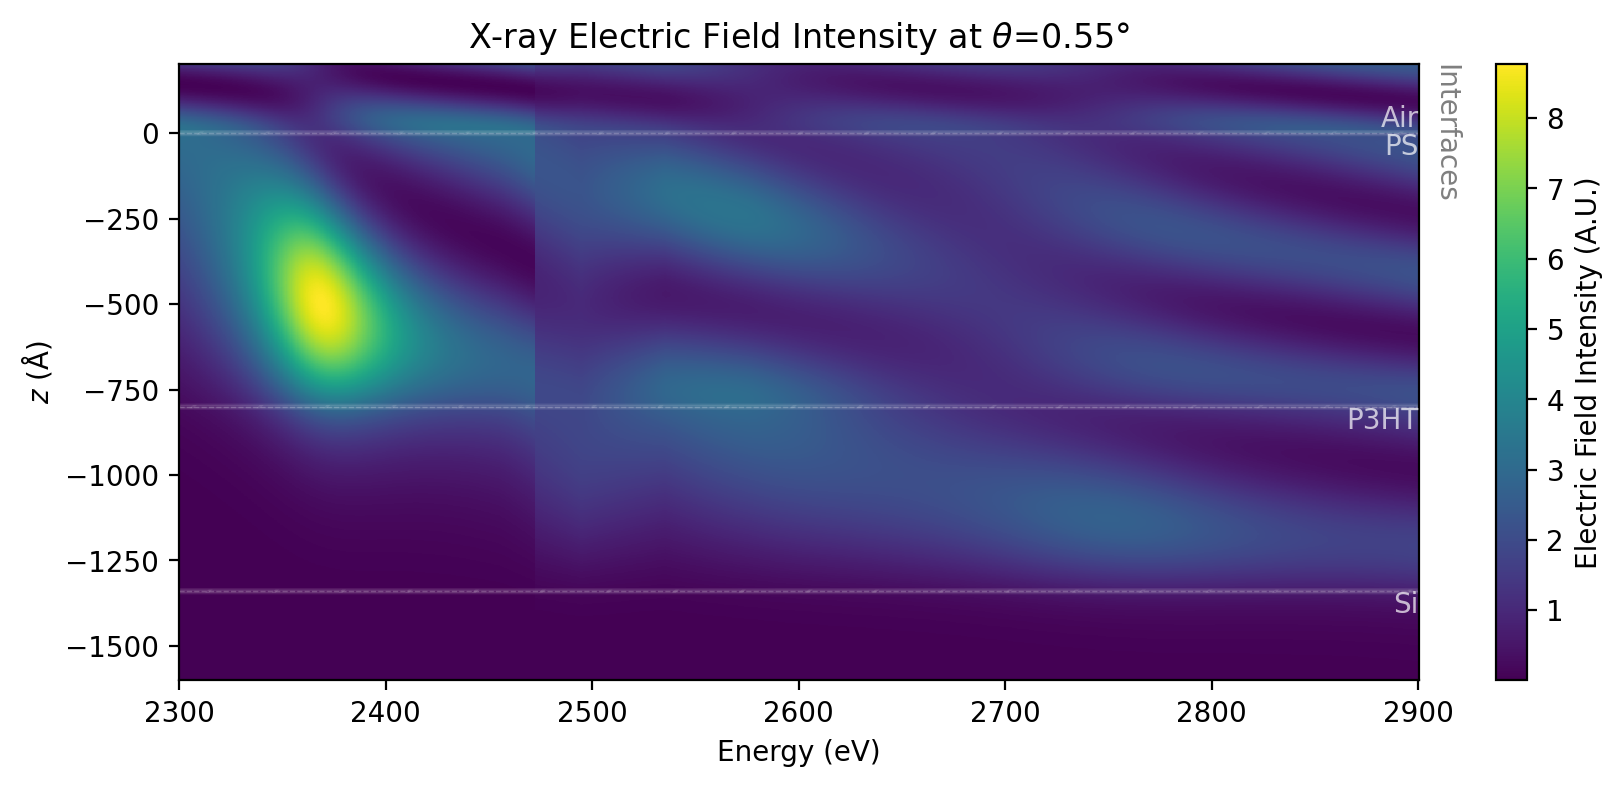

In [5]:
z_vals = np.linspace(200, -1600, 1000)
fig, ax = result.generate_graphic_XEFI_map(z_vals)
ax.set_title(rf"X-ray Electric Field Intensity at $\theta$={angle:0.2f}°")

### With Roughness

In [6]:
result = XEFI.XEF_Basic(
    energies=beam_energies,
    angles=angle,
    z=z,
    refractive_indices=refractive_indicies,
    z_roughness=[30, 15, 5],
    layer_names=labels,
    method=XEFI.XEF_method.DEV,
)

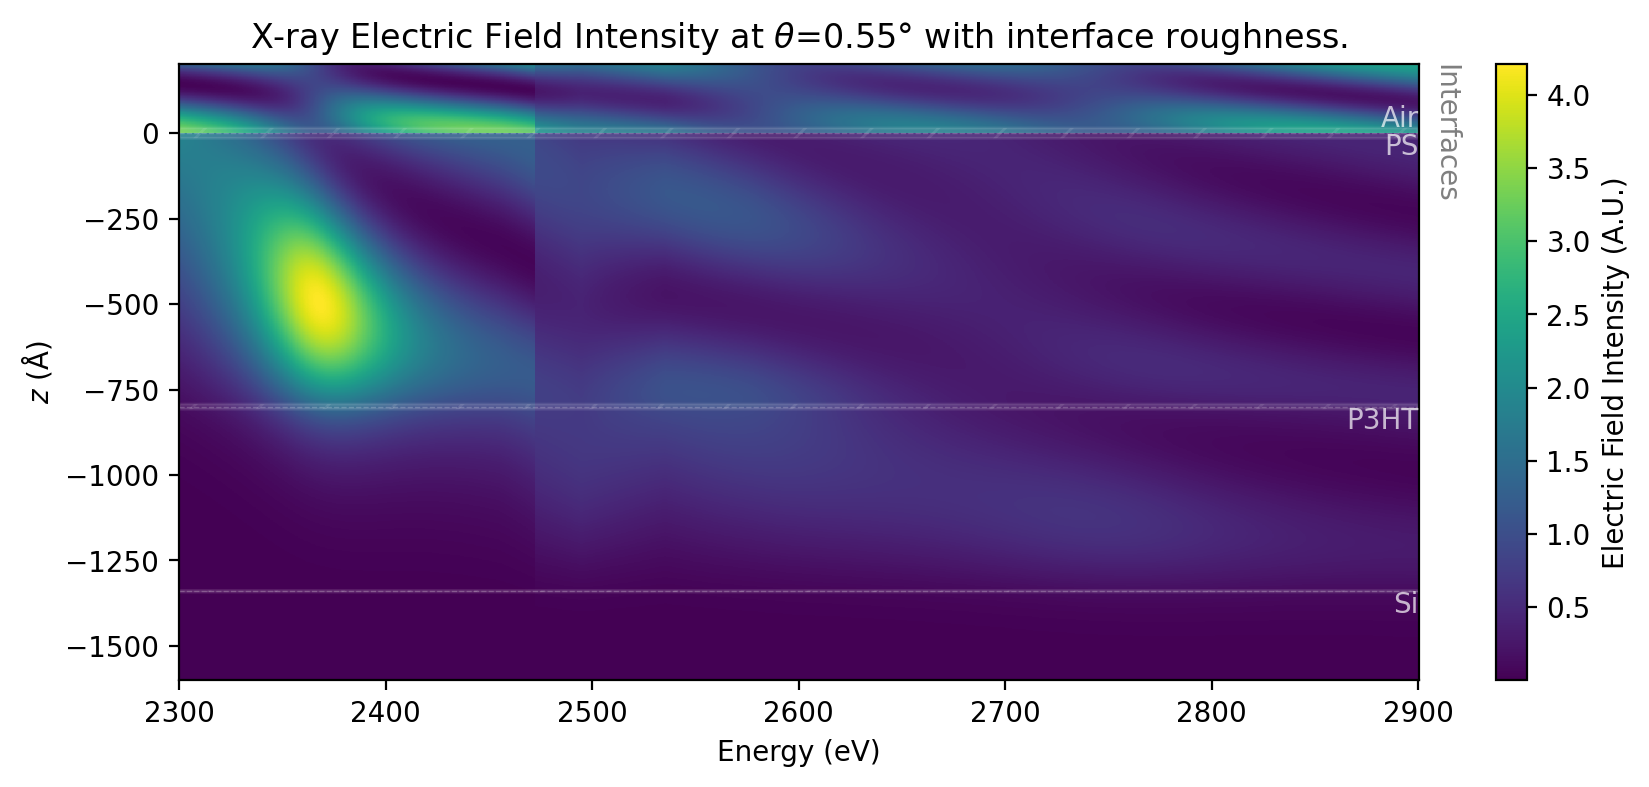

In [7]:
z_vals = np.linspace(200, -1600, 1000)
fig, ax = result.generate_graphic_XEFI_map(
    z_vals, grid_roughness=True, angles_in_deg=False
)
ax.set_title(
    rf"X-ray Electric Field Intensity at $\theta$={angle:0.2f}° with interface roughness."
);